## Next Steps

- More Dimensionality Reduction with specific (Find features that most correlate with rank type)
- More nonlinearity in the model
- ruboost

## Classifying Interaction Rank (Dominant vs Subordinate)

In [61]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedGroupKFold

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path


In [62]:
# Load raw feature matrix only — no inline z-score / ratio backfill (that hurt baseline performance)
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features-Rank-balanced-Interactions")

DATA_DIR = Path(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data")
RESP_PATHS_PATH = DATA_DIR / "resp_paths_interactions_rank.pkl"
resp_paths_lookup = pd.read_pickle(RESP_PATHS_PATH) if RESP_PATHS_PATH.exists() else {}

feature_matrix.columns

Index(['Behavior', 'Initiator', 'Start', 'Stop', 'Duration', 'PreBoutRespRate', 'Trial', 'Subject', 'social_agent', 'Cohort',
       ...
       'exhale_duty_cycle_z_subject', 'exhale_duty_cycle_z_trial', 'resp_rate_delta_z_subject', 'resp_rate_delta_z_trial', 'breathing_rate_z_z_subject', 'breathing_rate_z_z_trial', 'vol_asymmetry_z_subject', 'vol_asymmetry_z_trial', 'peak_flow_ratio_z_subject', 'peak_flow_ratio_z_trial'], dtype='object', length=110)

### Attempt at Balancing out Dom/Sub Classes

In [63]:
# Balance sniffing bouts so number of subordinate and dominant examples is equal *within subjects* AND *across behaviors*,
# AND also ensure counts are balanced at the global level. This avoids cohort/subject imbalance, producing a fairer split for ML/stat analysis.

def sample_balanced_per_subject_behavior(group, col="Rank", max_per_class=None, random_state=42):
    """
    For a DataFrame group (all bouts from one subject & behavior),
    randomly downsample so number of 'Dominant'/'Subordinate' (or provided classes) is matched.
    If max_per_class is set, also limit to that number per class.
    """
    classes = group[col].dropna().unique()
    # Only care if more than 1 class present
    if len(classes) < 2:
        return group
    min_count = group[col].value_counts().min()
    use_n = min_count if max_per_class is None else min(min_count, max_per_class)
    out = (
        group.groupby(col, group_keys=False)
             .apply(lambda x: x.sample(n=use_n, random_state=random_state) if len(x) > use_n else x)
    )
    return out

sniff_behaviors = ["facial sniffing", "body sniffing", "anogenital sniffing"]

# Restrict to relevant sniffing types and rows with valid Rank
balanced_df = (
    feature_matrix[
        feature_matrix["Behavior"].isin(sniff_behaviors) &
        feature_matrix["Rank"].notna()
    ]
    .copy()
)

# Downsample per subject *and* per behavior, i.e. groups of (Subject, Behavior)
balanced_df = (
    balanced_df
    .groupby(["Subject", "Behavior"], group_keys=False)
    .apply(sample_balanced_per_subject_behavior)
    .reset_index(drop=True)
)

# --- Now, force global-level balance by additionally downsampling the majority class ---
# This is necessary because some subjects/behaviors are missing a class entirely, so there may still be imbalance.
rank_counts = balanced_df["Rank"].value_counts()
if len(rank_counts) >= 2:
    min_global_count = rank_counts.min()
    # Fix random_state for reproducibility
    balanced_final_df = (
        balanced_df.groupby("Rank", group_keys=False)
        .apply(lambda x: x.sample(n=min_global_count, random_state=42) if len(x) > min_global_count else x)
        .reset_index(drop=True)
    )
else:
    balanced_final_df = balanced_df.copy()

print("After global balancing, counts by Rank:")
print(balanced_final_df['Rank'].value_counts())

# Downstream plots and ML use the balanced matrix (not the raw pickle).
feature_matrix = balanced_final_df.reset_index(drop=True).copy()
plot_df = feature_matrix

After global balancing, counts by Rank:
Rank
Dominant       299
Subordinate    299
Name: count, dtype: int64


C:\Users\thoma\AppData\Local\Temp\ipykernel_10572\579022965.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_balanced_per_subject_behavior)
C:\Users\thoma\AppData\Local\Temp\ipykernel_10572\579022965.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_global_count, random_state=42) if len(x) > min_global_count else x)


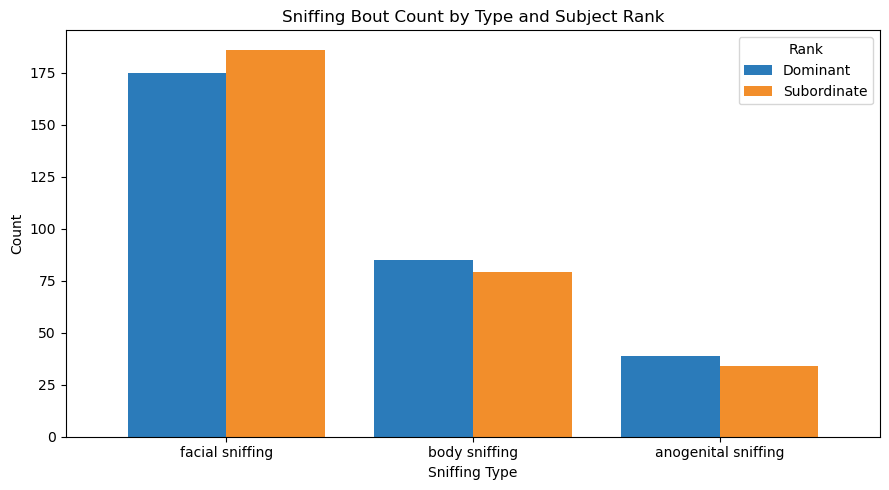

In [64]:
# Prepare a grouped bar plot: x-axis is Behavior (sniffing type), grouped by Rank
# feature_matrix was balanced in the cell above (sniffing types + matched Rank counts)
sniff_behaviors = ["facial sniffing", "body sniffing", "anogenital sniffing"]
plot_df = feature_matrix.copy()

rank_order = sorted(plot_df["Rank"].unique())
behavior_order = sniff_behaviors

# Count by [Behavior, Rank]
count_df = (
    plot_df
    .groupby(["Behavior", "Rank"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=behavior_order, fill_value=0)
    .reindex(columns=rank_order)
)

# Plot
ax = count_df.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.8,
    color=["#2b7bba", "#f28e2b"][:len(rank_order)]
)
plt.title("Sniffing Bout Count by Type and Subject Rank")
plt.ylabel("Count")
plt.xlabel("Sniffing Type")
plt.legend(title="Rank")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
feature_matrix.head()

,Behavior,Initiator,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,social_agent,Cohort,Rank,Type,h5_path,h5_filename,boris_path,boris_filename,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,subject,7.067,9.067,2.0,11.140584,AIM1cm_2_4_2_3_20250623_143348,2_4,2_3,Aim1,Dominant,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348.1_VT.csv,full,23,11.398964,0.087727,0.053596,0.040326,0.156520,0.042500,0.156115,...,-0.264308,NaN,NaN,-0.259105,-0.259105,-0.575275,-0.575275,-0.515181,-0.515181,NaN,NaN,-0.390655,-0.390655,0.458168,0.458168,-0.329048,-0.329048,0.110255,0.110255,1.685617,1.685617,0.628749,0.628749,0.135993,0.135993
1,facial sniffing,social_agent,7.367,9.367,2.0,11.224490,AIM1cm_2_4_2_3_20250623_143348,2_4,2_3,Aim1,Dominant,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348.1_VT.csv,full,22,10.894942,0.091786,0.201585,0.041705,0.358484,0.044205,0.153834,...,-0.264308,NaN,NaN,-0.259105,-0.259105,-0.575275,-0.575275,-0.515181,-0.515181,NaN,NaN,-0.390655,-0.390655,0.366119,0.366119,-0.370079,-0.370079,-0.246866,-0.246866,1.448501,1.448501,0.128880,0.128880,-0.490043,-0.490043
2,anogenital sniffing,subject,9.367,11.367,2.0,10.894942,AIM1cm_2_4_2_3_20250623_143348,2_4,2_3,Aim1,Dominant,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348.1_VT.csv,full,22,11.125828,0.089881,0.101010,0.037273,0.153895,0.047955,0.180344,...,-0.264308,NaN,NaN,-0.259105,-0.259105,-0.575275,-0.575275,-0.515181,-0.515181,NaN,NaN,-0.390655,-0.390655,-0.322095,-0.322095,0.377506,0.377506,0.093554,0.093554,1.557121,1.557121,-0.827196,-0.827196,-0.993752,-0.993752
3,body sniffing,subject,10.567,12.567,2.0,11.111111,AIM1cm_2_4_2_3_20250623_143348,2_4,2_3,Aim1,Dominant,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348.1_VT.csv,full,19,9.638554,0.103750,0.242199,0.041711,0.179340,0.056447,0.400363,...,-0.264308,NaN,NaN,-0.259105,-0.259105,-0.575275,-0.575275,-0.515181,-0.515181,NaN,NaN,-0.390655,-0.390655,-0.541693,-0.541693,0.529203,0.529203,-0.941156,-0.941156,0.857438,0.857438,-0.789980,-0.789980,-0.565936,-0.565936
4,facial sniffing,subject,12.200,14.200,2.0,10.165184,AIM1cm_2_4_2_3_20250623_143348,2_4,2_3,Aim1,Dominant,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_4_sub2_3_20250623_143348.1_VT.csv,full,18,10.014728,0.099853,0.107420,0.043472,0.130209,0.053056,0.235369,...,-0.264308,NaN,NaN,-0.259105,-0.259105,-0.079380,-0.079380,1.082818,1.082818,NaN,NaN,0.383053,0.383053,0.036463,0.036463,0.345876,0.345876,-0.138082,-0.138082,1.034408,1.034408,-0.244098,-0.244098,-0.217427,-0.217427


In [75]:
import numpy as np

# Remove metadata columns except 'Behavior'
metadata_cols = [
    'Initiator', 'Start', 'Stop', 'Trial', 'Subject', 'social_agent', 'Cohort',
    'Rank', 'Type', 'h5_path', 'h5_filename', 'boris_path', 'boris_filename',
    'FeatureWindow', 'Condition', 'SessionRate', 'BoutID', 'PreBoutRespRate'
]
non_feature_cols = ['Behavior'] + [col for col in feature_matrix.columns if (
    feature_matrix[col].dtype == 'O' or col in metadata_cols
) and col != 'Behavior']

resp_features = [col for col in feature_matrix.columns if col not in non_feature_cols]

# Print the most correlating feature pairs for each Rank group
for group_label in feature_matrix['Rank'].unique():
    group_df = feature_matrix[feature_matrix['Rank'] == group_label]
    sub_df = group_df[resp_features].copy()
    # Only include columns with more than 1 value and at least 2 non-NaN entries
    valid_cols = [
        col for col in sub_df.columns
        if sub_df[col].notna().sum() > 1 and sub_df[col].nunique(dropna=True) > 1
    ]
    corr = sub_df[valid_cols].corr(method='pearson')
    corr_vals = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
    # Find the single most correlated pair (absolute value)
    stack_corr = corr_vals.stack()
    if stack_corr.empty:
        print(f"\nNo valid correlations for Rank {group_label}")
        continue
    max_pair = stack_corr.idxmax()
    max_val = stack_corr.max()
    print(f"\nRank: {group_label}")
    print(f"  Most correlated features: {max_pair[0]} <-> {max_pair[1]} | r = {corr.loc[max_pair[0], max_pair[1]]:.2f}")


Rank: Dominant
  Most correlated features: cv_inhale_pause_dur <-> cv_inhale_pause_dur_z_subject | r = 1.00

Rank: Subordinate
  Most correlated features: breathing_rate_z <-> breathing_rate_hz_z_trial | r = 1.00


In [66]:
len(feature_matrix)

598

In [67]:
print("Rank labels:")
print(feature_matrix["Rank"].value_counts(dropna=False))
print("\nWindow type:")
print(feature_matrix["Type"].value_counts(dropna=False))

Rank labels:
Rank
Dominant       299
Subordinate    299
Name: count, dtype: int64

Window type:
Type
Interaction    598
Name: count, dtype: int64


### Split datasets: BLA cagemate only vs all cohorts

In [68]:
def is_bla_cagemate(row):
    return str(row["Trial"]).startswith("BLA") or str(row["Cohort"]).startswith("BLA")


interactions = feature_matrix[feature_matrix["Type"] == "Interaction"].copy()

feature_matrix_bla = interactions[interactions.apply(is_bla_cagemate, axis=1)].reset_index(drop=True)
feature_matrix_all = interactions.reset_index(drop=True)

DATASETS = {
    "BLA cagemate only": feature_matrix_bla,
    "All cohorts": feature_matrix_all,
}

for name, fm in DATASETS.items():
    print(f"\n{name}: {len(fm)} rows | {fm['Trial'].nunique()} trials | {fm['Subject'].nunique()} subjects")
    if "Condition" in fm.columns:
        print(fm["Condition"].value_counts().to_string())
    print(fm["Rank"].value_counts().to_string())


BLA cagemate only: 376 rows | 9 trials | 8 subjects
Rank
Subordinate    209
Dominant       167

All cohorts: 598 rows | 14 trials | 13 subjects
Rank
Dominant       299
Subordinate    299


### Clarifying Features and Targets

In [69]:
# Rank classification: Dominant vs Subordinate during interaction bouts
TARGET_COL = "Rank"
TARGET_CLASSES = ["Dominant", "Subordinate"]
MAX_MISSING_FRAC = 0.40

EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Condition",
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Type",
    "Label",
    "h5_path",
    "FeatureWindow",
}
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

ENGINEERED_FEATURE_COLS = {"vol_asymmetry", "peak_flow_ratio"}

TOP_VOLUME_FLOW_FEATS = [
    "mean_exhale_vol", "mean_tidal_vol_proxy", "ventilation_proxy",
    "mean_peak_exp_flow", "mean_peak_insp_flow", "mean_inhale_vol",
    "mean_inhale_dur_sec", "cv_ibi",
]
TOP_PLUS_RATIOS = TOP_VOLUME_FLOW_FEATS + ["vol_asymmetry", "peak_flow_ratio"]


def _is_engineered_feature(col):
    return (
        col in ENGINEERED_FEATURE_COLS
        or col.endswith("_z_subject")
        or col.endswith("_z_trial")
    )


def _baseline_numeric_cols(df):
    return [
        c for c in df.columns
        if c not in EXCLUDE_FROM_FEATURES
        and pd.api.types.is_numeric_dtype(df[c])
        and not _is_engineered_feature(c)
    ]


def add_ratio_features(df):
    df = df.copy()
    if {"mean_inhale_vol", "mean_exhale_vol"}.issubset(df.columns):
        df["vol_asymmetry"] = df["mean_inhale_vol"] / (df["mean_exhale_vol"].abs() + 1e-8)
    if {"mean_peak_insp_flow", "mean_peak_exp_flow"}.issubset(df.columns):
        df["peak_flow_ratio"] = df["mean_peak_insp_flow"] / (df["mean_peak_exp_flow"].abs() + 1e-8)
    return df


def add_z_features(df):
    df = df.copy()
    for col in _baseline_numeric_cols(df):
        df[f"{col}_z_subject"] = df.groupby("Subject")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        df[f"{col}_z_trial"] = df.groupby("Trial")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
    return df


def _resolve_feature_cols(kept_cols, feature_set):
    if feature_set in ("baseline", "all"):
        return [c for c in kept_cols if not _is_engineered_feature(c)]
    if feature_set == "top_volume_flow":
        return [c for c in TOP_VOLUME_FLOW_FEATS if c in kept_cols]
    if feature_set == "top_plus_ratios":
        return [c for c in TOP_PLUS_RATIOS if c in kept_cols]
    if feature_set == "z_subject":
        return [c for c in kept_cols if c.endswith("_z_subject")]
    if feature_set == "z_trial":
        return [c for c in kept_cols if c.endswith("_z_trial")]
    if feature_set == "top_z_subject":
        return [f"{c}_z_subject" for c in TOP_VOLUME_FLOW_FEATS if f"{c}_z_subject" in kept_cols]
    raise ValueError(f"Unknown feature_set: {feature_set}")


def prepare_rank_dataset(
    fm,
    max_missing_frac=MAX_MISSING_FRAC,
    feature_set="baseline",
    behavior=None,
    add_ratios=False,
    add_z=False,
):
    """Filter to labeled interaction windows and build X / y / groups.

    Default (baseline): original raw BreathMetrics features only — no auto engineering.
    Pass add_ratios=True / add_z=True (or use feature_set) only in ablation experiments.
    """
    df = fm.copy()
    if add_ratios or feature_set == "top_plus_ratios":
        df = add_ratio_features(df)
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        df = add_z_features(df)

    if "Type" in df.columns:
        df = df[df["Type"] == "Interaction"].copy()
    df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)
    if behavior is not None:
        df = df[df["Behavior"] == behavior].reset_index(drop=True)

    candidate_feature_cols = _baseline_numeric_cols(df)
    if add_ratios or feature_set == "top_plus_ratios":
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + ["vol_asymmetry", "peak_flow_ratio"]))
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        z_cols = [c for c in df.columns if c.endswith("_z_subject") or c.endswith("_z_trial")]
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + z_cols))

    X_all = df[candidate_feature_cols].copy()
    y = df[TARGET_COL].copy()

    groups = None
    if "Subject" in df.columns:
        groups = df["Subject"].copy()
    elif "Trial" in df.columns:
        groups = df["Trial"].copy()

    missing_frac = X_all.isna().mean(axis=0)
    kept_feature_cols = missing_frac[missing_frac <= max_missing_frac].index.tolist()
    dropped_feature_cols = missing_frac[missing_frac > max_missing_frac].sort_values(ascending=False)
    selected_feature_cols = _resolve_feature_cols(kept_feature_cols, feature_set)
    X = X_all[selected_feature_cols].copy()

    return {
        "df": df,
        "X_all": X_all,
        "X": X,
        "y": y,
        "groups": groups,
        "candidate_feature_cols": candidate_feature_cols,
        "kept_feature_cols": kept_feature_cols,
        "selected_feature_cols": selected_feature_cols,
        "dropped_feature_cols": dropped_feature_cols,
        "feature_set": feature_set,
        "behavior": behavior,
    }


dataset_prepared = {name: prepare_rank_dataset(fm) for name, fm in DATASETS.items()}

### Building Pipelines

In [70]:
# Preprocessing + model pipeline templates (reused for each dataset)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

MODELS = {
    "LogisticRegression": logreg_clf,
    "SVM": svm_clf,
    "RandomForest": rf_clf,
}

for dataset_name, prep in dataset_prepared.items():
    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)
    print(f"Rows retained after target filter: {len(prep['df'])}")
    print(f"Target class counts:\n{prep['y'].value_counts(dropna=False)}\n")
    print(f"Candidate numeric resp features: {len(prep['candidate_feature_cols'])}")
    print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {prep['X'].shape[1]}")
    print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(prep['dropped_feature_cols'])}")
    if len(prep["dropped_feature_cols"]):
        print("Dropped columns and missing fraction:")
        display(prep["dropped_feature_cols"].to_frame(name="missing_fraction"))
    print(f"X shape: {prep['X'].shape}")
    print(f"y shape: {prep['y'].shape}")
    print(f"groups available: {prep['groups'] is not None}")
    if prep["groups"] is not None:
        n_splits = min(5, prep["groups"].nunique())
        print(f"CV strategy: GroupKFold / StratifiedGroupKFold (n_splits={n_splits})")
    else:
        print("CV strategy: StratifiedKFold(n_splits=5)")


DATASET: BLA cagemate only
Rows retained after target filter: 376
Target class counts:
Rank
Subordinate    209
Dominant       167
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.986702
cv_exhale_pause_dur,0.922872


X shape: (376, 25)
y shape: (376,)
groups available: True
CV strategy: GroupKFold / StratifiedGroupKFold (n_splits=5)

DATASET: All cohorts
Rows retained after target filter: 598
Target class counts:
Rank
Dominant       299
Subordinate    299
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.991639
cv_exhale_pause_dur,0.914716


X shape: (598, 25)
y shape: (598,)
groups available: True
CV strategy: GroupKFold / StratifiedGroupKFold (n_splits=5)


### Running Pipelines/Models

In [71]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


def make_split_iterator(X, y, groups, cv_mode="stratified_group"):
    if cv_mode == "loso" and groups is not None and pd.Series(groups).nunique() >= 3:
        return LeaveOneGroupOut().split(X, y, groups=groups), "LeaveOneGroupOut (by Subject)"
    if groups is not None and pd.Series(groups).nunique() >= 3:
        n_splits_eval = min(5, pd.Series(groups).nunique())
        return (
            StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y, groups=groups),
            f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True)",
        )
    n_splits_eval = 5
    return (
        StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42).split(X, y),
        "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    )


def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator, X, y, classes, verbose=True):
    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)
        y_pred = model.predict(X_test)

        present_classes = np.sort(y_test.unique())
        bal_acc = recall_score(y_test, y_pred, labels=present_classes, average="macro", zero_division=0)
        macro_f1 = f1_score(y_test, y_pred, labels=present_classes, average="macro", zero_division=0)

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(y_test, y_pred, labels=present_classes, average=None, zero_division=0)
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        if verbose:
            print(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)
    if verbose:
        print(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
        print(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")
        print(f"\n[{model_name}] Mean per-class recall across folds:")
        for i, cls in enumerate(classes):
            print(f"  {cls}: {np.nanmean(per_class_recall[:, i]):.3f} +/- {np.nanstd(per_class_recall[:, i]):.3f}")
        print(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
        print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
        display(cm_df)

    return {
        "balanced_acc_mean": float(np.mean(bal_acc_scores)),
        "balanced_acc_std": float(np.std(bal_acc_scores)),
        "macro_f1_mean": float(np.mean(macro_f1_scores)),
        "macro_f1_std": float(np.std(macro_f1_scores)),
    }


model_results = []

for dataset_name, prep in dataset_prepared.items():
    X, y, groups = prep["X"], prep["y"], prep["groups"]
    _, cv_eval_mode = make_split_iterator(X, y, groups)
    classes = np.sort(y.unique())
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

    print("\n" + "#" * 80)
    print(f"MODEL EVALUATION — {dataset_name}")
    print("#" * 80)
    print(f"CV for evaluation: {cv_eval_mode}")
    print("Computed balanced class weights:", dict(zip(classes, class_weights)))

    for model_name, pipeline in MODELS.items():
        split_iter, _ = make_split_iterator(X, y, groups)
        print("\n" + "-" * 80)
        metrics = evaluate_imbalanced_pipeline(
            pipeline, model_name, split_iter, X, y, classes
        )
        model_results.append({"dataset": dataset_name, "model": model_name, **metrics})

results_summary_df = pd.DataFrame(model_results)
print("\n" + "=" * 80)
print("CROSS-DATASET MODEL COMPARISON")
print("=" * 80)
display(results_summary_df.sort_values(["dataset", "balanced_acc_mean"], ascending=[True, False]))

# Use combined dataset for exploratory plots below
df = dataset_prepared["All cohorts"]["df"]
X = dataset_prepared["All cohorts"]["X"]
y = dataset_prepared["All cohorts"]["y"]
groups = dataset_prepared["All cohorts"]["groups"]


################################################################################
MODEL EVALUATION — BLA cagemate only
################################################################################
CV for evaluation: StratifiedGroupKFold(n_splits=5, shuffle=True)
Computed balanced class weights: {'Dominant': np.float64(1.125748502994012), 'Subordinate': np.float64(0.8995215311004785)}

--------------------------------------------------------------------------------
[LogisticRegression] Fold 1: balanced_acc=0.321, macro_f1=0.486
[LogisticRegression] Fold 2: balanced_acc=0.534, macro_f1=0.696
[LogisticRegression] Fold 3: balanced_acc=0.328, macro_f1=0.192


[LogisticRegression] Fold 4: balanced_acc=0.454, macro_f1=0.453
[LogisticRegression] Fold 5: balanced_acc=0.021, macro_f1=0.042

[LogisticRegression] Mean balanced accuracy: 0.332 +/- 0.175
[LogisticRegression] Mean macro F1: 0.374 +/- 0.231

[LogisticRegression] Mean per-class recall across folds:
  Dominant: 0.124 +/- 0.103
  Subordinate: 0.518 +/- 0.120

[LogisticRegression] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.18      0.12      0.14       167
 Subordinate       0.44      0.56      0.49       209

    accuracy                           0.36       376
   macro avg       0.31      0.34      0.32       376
weighted avg       0.32      0.36      0.34       376



,pred_Dominant,pred_Subordinate
true_Dominant,20,147
true_Subordinate,93,116



--------------------------------------------------------------------------------
[SVM] Fold 1: balanced_acc=0.571, macro_f1=0.727
[SVM] Fold 2: balanced_acc=0.726, macro_f1=0.841
[SVM] Fold 3: balanced_acc=0.403, macro_f1=0.399
[SVM] Fold 4: balanced_acc=0.425, macro_f1=0.397
[SVM] Fold 5: balanced_acc=0.043, macro_f1=0.082

[SVM] Mean balanced accuracy: 0.434 +/- 0.227
[SVM] Mean macro F1: 0.489 +/- 0.270

[SVM] Mean per-class recall across folds:
  Dominant: 0.222 +/- 0.213
  Subordinate: 0.583 +/- 0.184

[SVM] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.39      0.26      0.31       167
 Subordinate       0.53      0.67      0.59       209

    accuracy                           0.49       376
   macro avg       0.46      0.47      0.45       376
weighted avg       0.47      0.49      0.47       376



,pred_Dominant,pred_Subordinate
true_Dominant,44,123
true_Subordinate,69,140


...

,pred_Dominant,pred_Subordinate
true_Dominant,151,148
true_Subordinate,179,120



--------------------------------------------------------------------------------
[RandomForest] Fold 1: balanced_acc=0.072, macro_f1=0.071
[RandomForest] Fold 2: balanced_acc=0.158, macro_f1=0.178
[RandomForest] Fold 3: balanced_acc=0.315, macro_f1=0.479
[RandomForest] Fold 4: balanced_acc=0.530, macro_f1=0.337
[RandomForest] Fold 5: balanced_acc=0.483, macro_f1=0.396

[RandomForest] Mean balanced accuracy: 0.312 +/- 0.178
[RandomForest] Mean macro F1: 0.292 +/- 0.148

[RandomForest] Mean per-class recall across folds:
  Dominant: 0.118 +/- 0.090
  Subordinate: 0.466 +/- 0.294

[RandomForest] Classification report (pooled out-of-fold predictions):
              precision    recall  f1-score   support

    Dominant       0.20      0.15      0.17       299
 Subordinate       0.32      0.41      0.36       299

    accuracy                           0.28       598
   macro avg       0.26      0.28      0.27       598
weighted avg       0.26      0.28      0.27       598



,pred_Dominant,pred_Subordinate
true_Dominant,44,255
true_Subordinate,177,122



CROSS-DATASET MODEL COMPARISON


,dataset,model,balanced_acc_mean,balanced_acc_std,macro_f1_mean,macro_f1_std
3,All cohorts,LogisticRegression,0.337152,0.157703,0.355851,0.211696
4,All cohorts,SVM,0.318463,0.168949,0.340491,0.205340
5,All cohorts,RandomForest,0.311650,0.177670,0.291907,0.148117
1,BLA cagemate only,SVM,0.433603,0.227341,0.489354,0.269544
2,BLA cagemate only,RandomForest,0.394855,0.252304,0.388126,0.302086
0,BLA cagemate only,LogisticRegression,0.331882,0.174691,0.373886,0.230776


In [72]:
print("\n\n" + "=" * 80)
print("RANK CLASSIFICATION DATASET SUMMARY")
print("=" * 80 + "\n")

for dataset_name, prep in dataset_prepared.items():
    dfi = prep["df"]
    print("-" * 80)
    print(dataset_name)
    print("-" * 80)
    print(f"Rows (interaction windows only): {len(dfi)}")
    print(f"Target distribution:\n{prep['y'].value_counts(dropna=False)}\n")
    print(f"Trials: {dfi['Trial'].nunique()} | Subjects: {dfi['Subject'].nunique()}")
    if "Condition" in dfi.columns:
        print(f"\nRecording condition breakdown:\n{dfi['Condition'].value_counts()}")
    print()



RANK CLASSIFICATION DATASET SUMMARY

--------------------------------------------------------------------------------
BLA cagemate only
--------------------------------------------------------------------------------
Rows (interaction windows only): 376
Target distribution:
Rank
Subordinate    209
Dominant       167
Name: count, dtype: int64

Trials: 9 | Subjects: 8

--------------------------------------------------------------------------------
All cohorts
--------------------------------------------------------------------------------
Rows (interaction windows only): 598
Target distribution:
Rank
Dominant       299
Subordinate    299
Name: count, dtype: int64

Trials: 14 | Subjects: 13




FEATURE INSPECTION — BLA cagemate only
Top features used in pairplot: ['pct_breaths_with_exhale_pause', 'breathing_rate_hz', 'n_breaths', 'pct_breaths_with_inhale_pause', 'mean_inhale_dur_sec', 'mean_ibi_sec']


,anova_f_score
pct_breaths_with_exhale_pause,5.949839
breathing_rate_hz,5.228092
n_breaths,4.835621
pct_breaths_with_inhale_pause,3.545984
mean_inhale_dur_sec,3.531393
mean_ibi_sec,3.028482
cv_peak_insp_flow,2.939113
mean_exhale_dur_sec,2.741299
ventilation_proxy,2.336833
mean_peak_insp_flow,1.549371


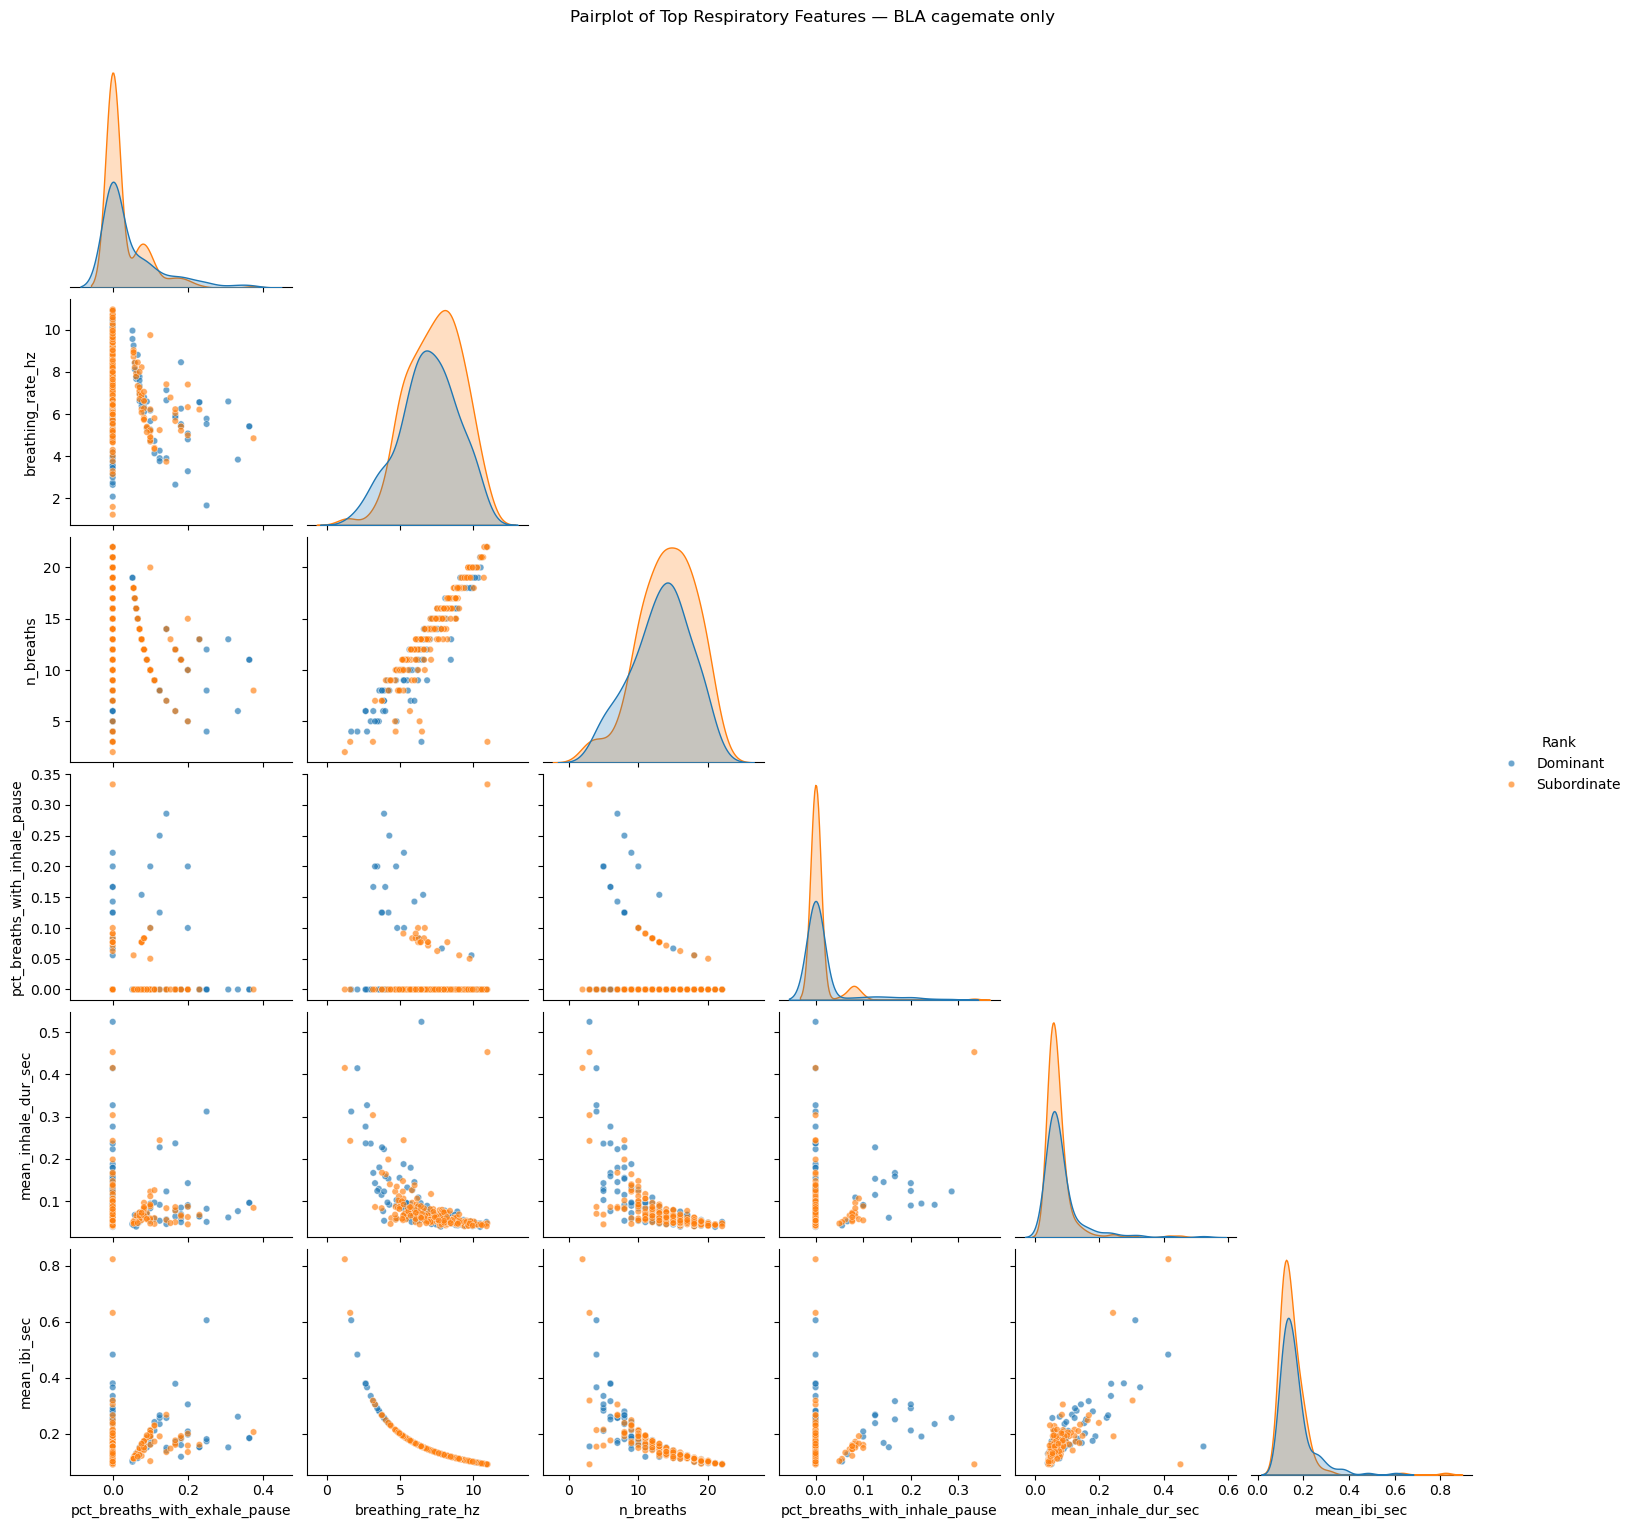

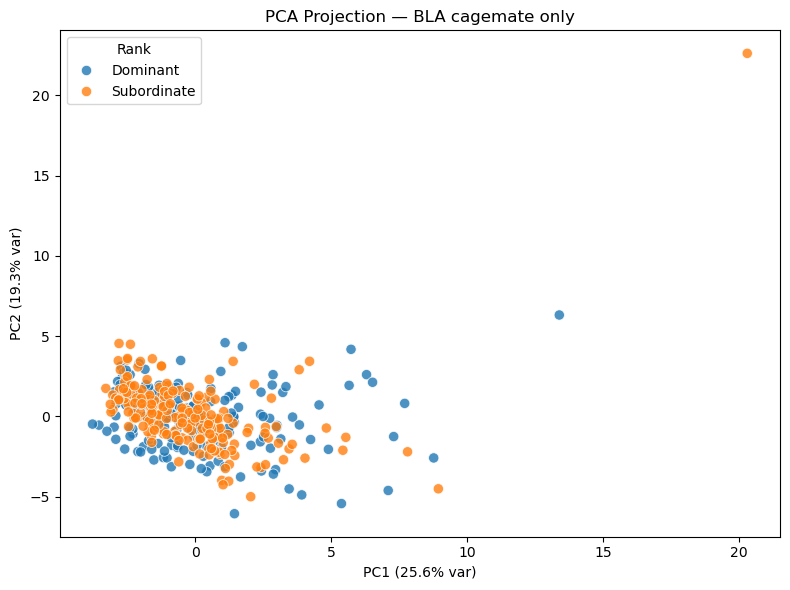

Total variance explained by PC1+PC2: 44.89%

FEATURE INSPECTION — All cohorts
Top features used in pairplot: ['pct_breaths_with_exhale_pause', 'mean_inhale_vol', 'pct_breaths_with_inhale_pause', 'cv_exhale_dur', 'mean_tidal_vol_proxy', 'mean_peak_insp_flow']


,anova_f_score
pct_breaths_with_exhale_pause,15.044432
mean_inhale_vol,5.315746
pct_breaths_with_inhale_pause,4.178150
cv_exhale_dur,3.931892
mean_tidal_vol_proxy,3.285707
mean_peak_insp_flow,2.870263
cv_inhale_dur,2.371715
breathing_rate_hz,2.281251
mean_ibi_sec,2.275753
mean_inhale_dur_sec,1.805964


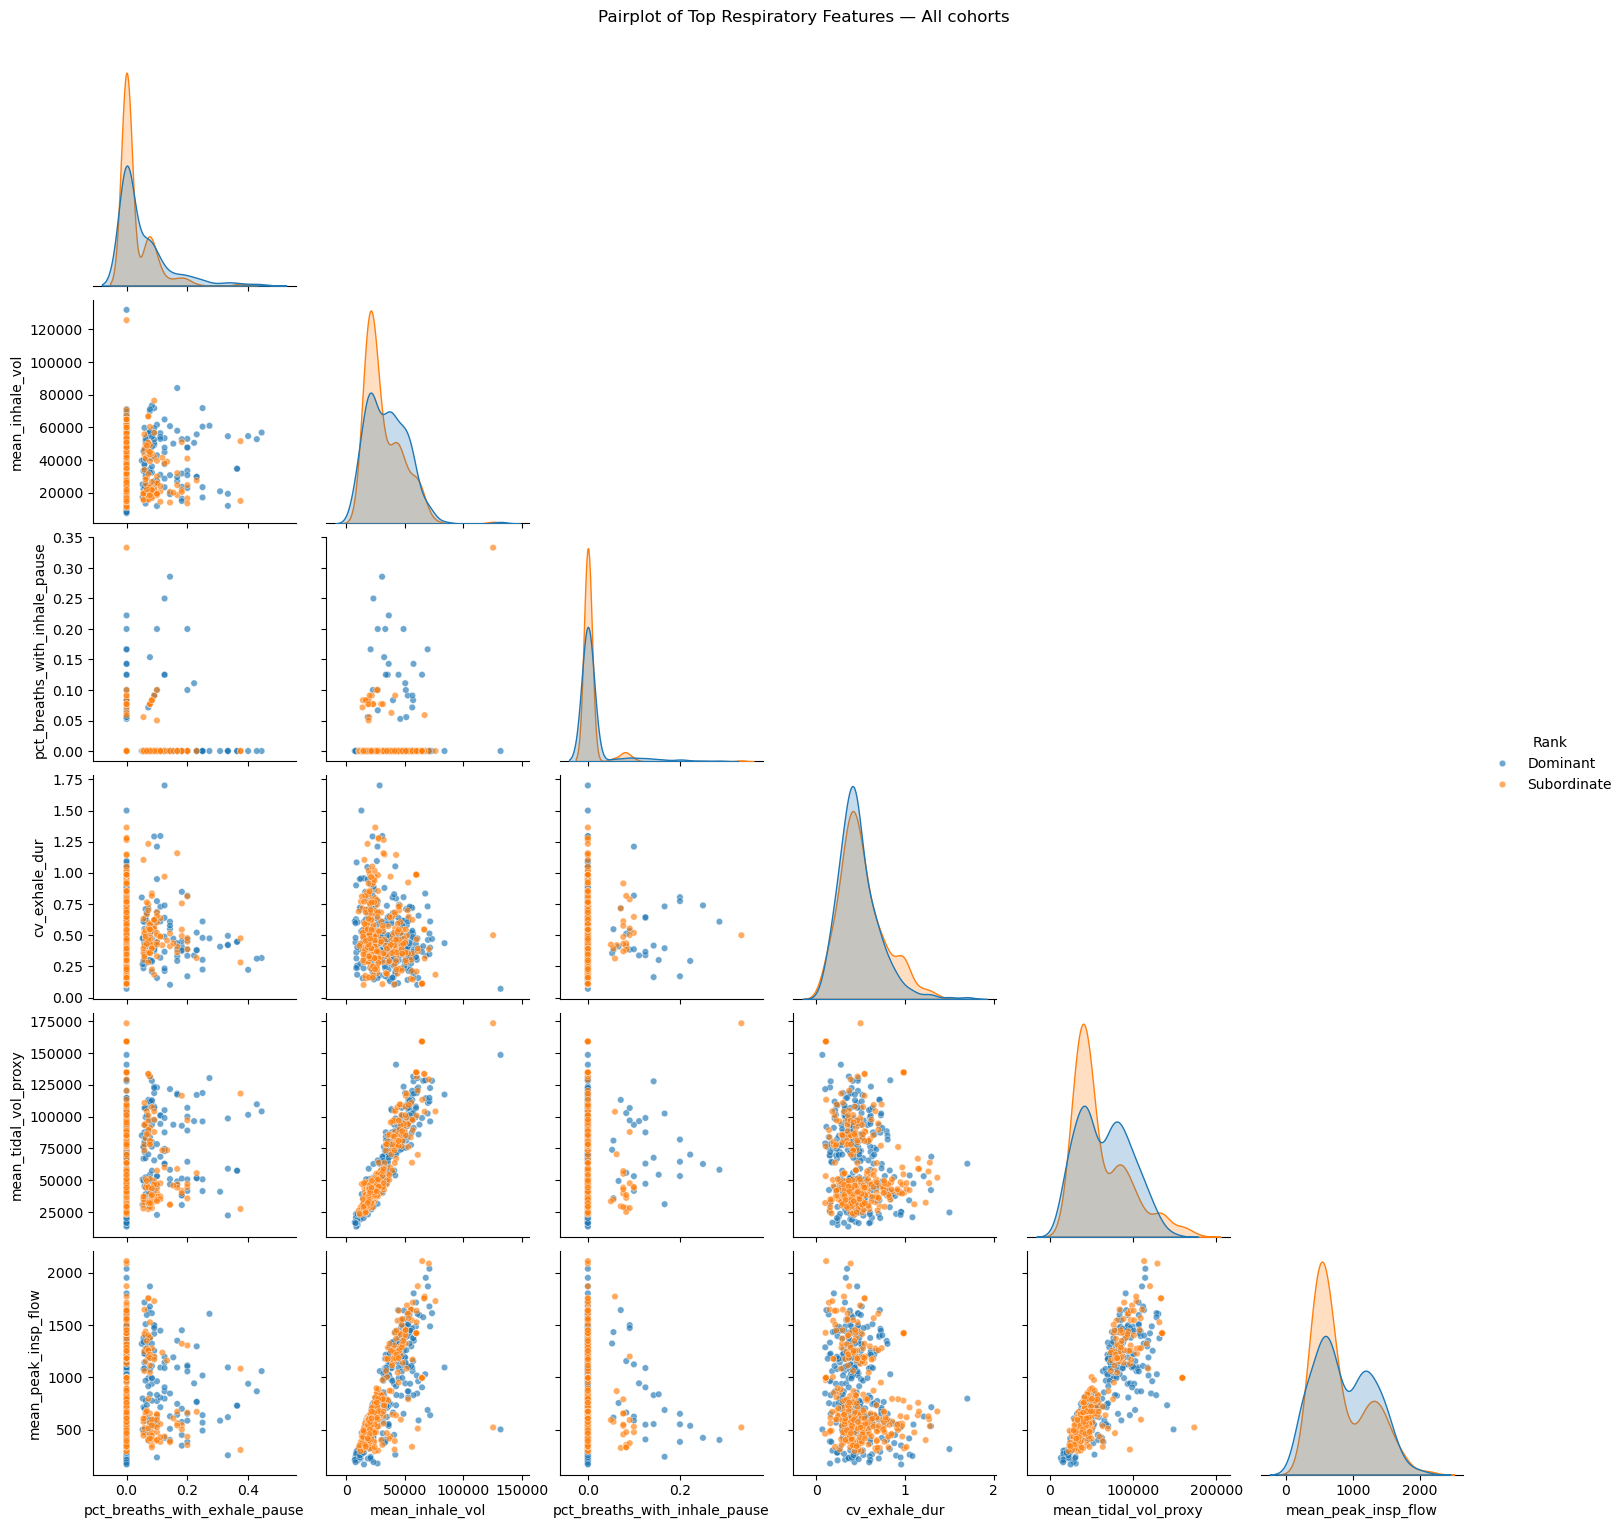

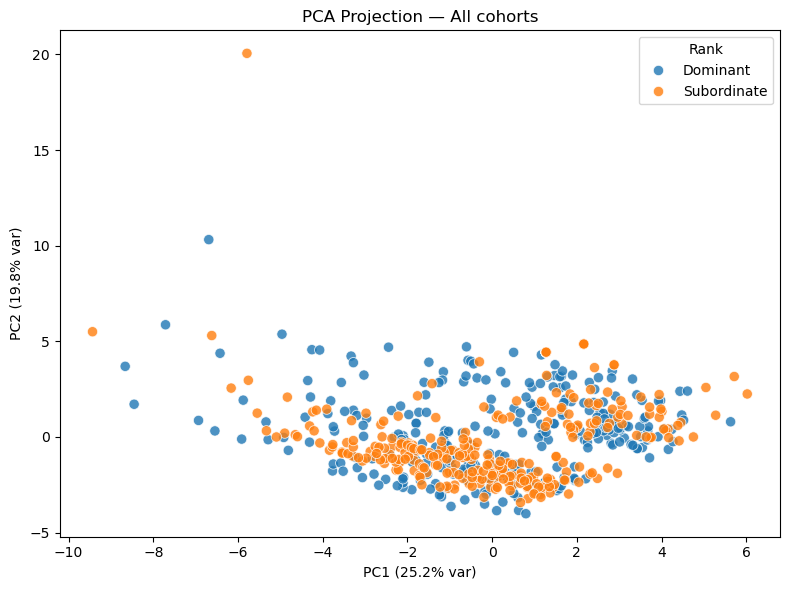

Total variance explained by PC1+PC2: 44.99%


In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif

N_TOP_FEATURES = 6


def inspect_pairplot_and_pca(prep, dataset_name, n_top_features=N_TOP_FEATURES):
    """Pairplot + PCA for one dataset split."""
    X_local = prep["X"]
    y_local = prep["y"]

    print("\n" + "=" * 80)
    print(f"FEATURE INSPECTION — {dataset_name}")
    print("=" * 80)

    imputer = SimpleImputer(strategy="median")
    X_vis = pd.DataFrame(imputer.fit_transform(X_local), columns=X_local.columns, index=X_local.index)

    f_scores, _ = f_classif(X_vis, y_local)
    feature_rank = pd.Series(f_scores, index=X_vis.columns).sort_values(ascending=False)
    top_features = feature_rank.head(n_top_features).index.tolist()

    print("Top features used in pairplot:", top_features)
    display(feature_rank.head(12).to_frame(name="anova_f_score"))

    pairplot_df = X_vis[top_features].copy()
    pairplot_df[TARGET_COL] = y_local.values

    g = sns.pairplot(
        pairplot_df,
        hue=TARGET_COL,
        corner=True,
        diag_kind="kde",
        plot_kws={"alpha": 0.65, "s": 22},
    )
    g.fig.suptitle(f"Pairplot of Top Respiratory Features — {dataset_name}", y=1.02)
    plt.show()

    X_vis_scaled = pd.DataFrame(
        StandardScaler().fit_transform(X_vis),
        columns=X_vis.columns,
        index=X_vis.index,
    )
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis_scaled)

    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
    pca_df[TARGET_COL] = y_local.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COL, alpha=0.8, s=55)
    plt.title(f"PCA Projection — {dataset_name}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
    plt.legend(title=TARGET_COL)
    plt.tight_layout()
    plt.show()

    print(
        f"Total variance explained by PC1+PC2: "
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
    )


for dataset_name, prep in dataset_prepared.items():
    inspect_pairplot_and_pca(prep, dataset_name)